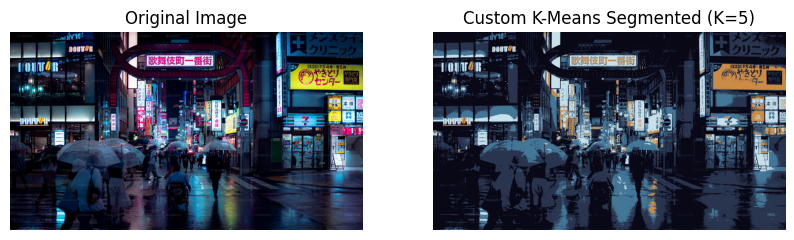

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def initialize_centroids(pixels, K):
    """Randomly initialize K cluster centroids from the pixel values."""
    indices = np.random.choice(len(pixels), K, replace=False)
    return pixels[indices]

def assign_clusters(pixels, centroids):
    """Assign each pixel to the closest centroid."""
    distances = np.linalg.norm(pixels[:, None] - centroids, axis=2)
    return np.argmin(distances, axis=1)

def update_centroids(pixels, labels, K):
    """Compute new centroids as the mean of assigned pixels."""
    new_centroids = np.array([pixels[labels == k].mean(axis=0) if np.any(labels == k) else pixels[np.random.randint(len(pixels))] for k in range(K)])
    return new_centroids

def kmeans_clustering(pixels, K, max_iters=20, tol=1e-4):
    """Custom implementation of K-Means clustering."""
    centroids = initialize_centroids(pixels, K)
    for _ in range(max_iters):
        labels = assign_clusters(pixels, centroids)
        new_centroids = update_centroids(pixels, labels, K)
        if np.linalg.norm(new_centroids - centroids) < tol:
            break
        centroids = new_centroids
    return labels, centroids

# Load the image
img = cv2.imread(r"C:\Users\JAI\Pictures\japan.jpg")  # Update path if needed
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Reshape the image into a 2D array of pixels
pixels = img.reshape((-1, 3)).astype(np.float32)

# Number of clusters
K = 5  # Adjust as needed

# Apply custom K-Means
labels, centroids = kmeans_clustering(pixels, K)

# Convert centers to uint8 and map labels to cluster colors
centroids = np.uint8(centroids)
segmented_image = centroids[labels].reshape(img.shape)

# Display original & segmented images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(segmented_image)
plt.title(f"Custom K-Means Segmented (K={K})")
plt.axis("off")

plt.show()


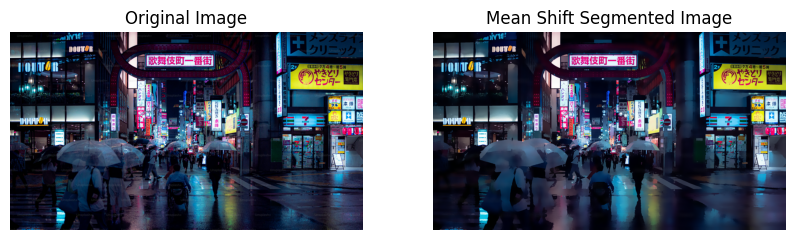

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread(r"C:\Users\JAI\Pictures\japan.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert image to a 2D array of pixel values
pixels = img.reshape((-1, 3))
pixels = np.float32(pixels)

# Apply Mean Shift using cv2.pyrMeanShiftFiltering
segmented_img = cv2.pyrMeanShiftFiltering(img, sp=20, sr=40)

# Display original and segmented images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(segmented_img)
plt.title("Mean Shift Segmented Image")
plt.axis("off")

plt.show()


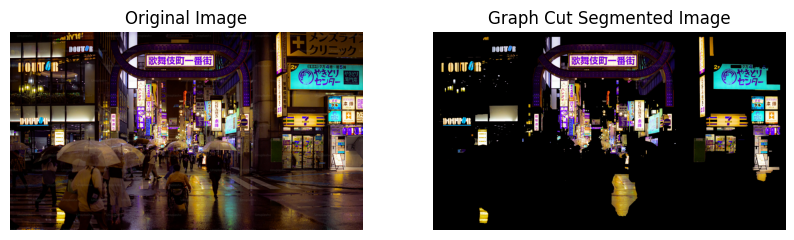

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load imageimg = cv2.imread("/download (2).jfif")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Create mask (same size as image, initialized to background)
mask = np.zeros(img.shape[:2], np.uint8)

# Background and foreground models (used internally by grabCut)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

# Define rectangle around the object (x, y, width, height)
rect = (50, 50, img.shape[1] - 100, img.shape[0] - 100)

# Apply GrabCut algorithm
cv2.grabCut(img, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)

# Modify mask to segment foreground
mask_final = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")
segmented_img = img * mask_final[:, :, np.newaxis]  # Apply mask to image

# Display results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(segmented_img)
plt.title("Graph Cut Segmented Image")
plt.axis("off")

plt.show()


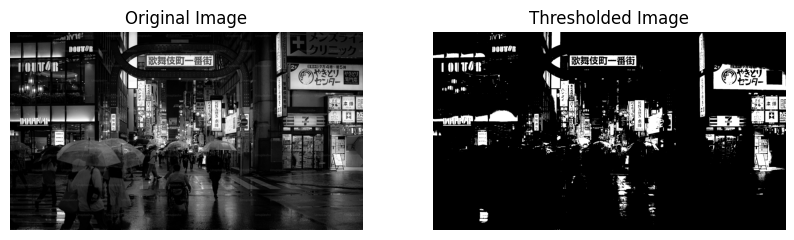

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image in grayscale
image = cv2.imread(r"C:\Users\JAI\Pictures\japan.jpg", cv2.IMREAD_GRAYSCALE)

# Define threshold value
threshold_value = 127

# Create an empty array for the thresholded image
binary_thresh = np.zeros_like(image)

# Apply manual thresholding
for i in range(image.shape[0]):
    for j in range(image.shape[1]):
        if image[i, j] > threshold_value:
            binary_thresh[i, j] = 255
        else:
            binary_thresh[i, j] = 0

# Show images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(binary_thresh, cmap="gray")
plt.title("Thresholded Image")
plt.axis("off")

plt.show()


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def region_growing(image, seed, threshold=25):
    rows, cols = image.shape
    segmented = np.zeros_like(image)
    visited = np.zeros_like(image, dtype=bool)
    seed_list = [seed]
    
    # Initialize region statistics
    region_pixels = [image[seed]]
    region_mean = np.mean(region_pixels)

    while seed_list:
        x, y = seed_list.pop(0)
        
        if visited[x, y]:
            continue
            
        visited[x, y] = True
        segmented[x, y] = 255  # Mark as white
        
        # Update region statistics
        region_pixels.append(image[x,y])
        region_mean = np.mean(region_pixels)

        # Check 8-neighbors
        for dx in (-1, 0, 1):
            for dy in (-1, 0, 1):
                nx, ny = x + dx, y + dy
                
                if 0 <= nx < rows and 0 <= ny < cols:
                    if not visited[nx, ny]:
                        pixel_value = image[nx, ny]
                        
                        # Compare using actual threshold value
                        if abs(int(pixel_value) - region_mean) <= threshold:
                            seed_list.append((nx, ny))

    return segmented


# Load grayscale image
image = cv2.imread(r"C:\Users\JAI\Pictures\uwp4719422 (1).png", cv2.IMREAD_GRAYSCALE)

# Define seed point manually (example: center of the image)
seed = (image.shape[0] // 2, image.shape[1] // 2)


# Perform region growing segmentation
segmented_image = region_growing(image, seed, threshold=50)

# Show results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(segmented_image, cmap="gray")
plt.title("Segmented Image")

plt.show()

